# Module 01 · The statistical learning frame

**Learning objectives.** By the end of this module you should be able to:

1. State prediction as a decision problem — loss, risk, empirical risk minimisation — and identify the Bayes-optimal predictor for a given loss;
2. Derive the optimal point predictions under squared and absolute loss, and explain why the choice of loss selects the functional of the conditional distribution being estimated;
3. Derive the bias–variance decomposition of squared-error risk, and use it to frame overfitting as estimator variance;
4. State precisely what cross-validation estimates — and what it does not;
5. Derive the optimism of in-sample error for linear smoothers via effective degrees of freedom, $\mathrm{df} = \operatorname{tr}(\mathbf{H})$, and verify it empirically.

**Prerequisites.** Module 00 (NumPy, pandas, and plotting conventions). Assumed background: probability at the level of conditional expectation, likelihood methods, and GLMs — all used freely.

**Estimated working time.** 4–5 hours including exercises.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

MODULE_SEED = 1
rng = np.random.default_rng(MODULE_SEED)

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.tunnel_mpl import apply_theme

apply_theme()

## 1 · Prediction as a decision problem

Supervised learning is a decision problem dressed in new vocabulary. We observe a feature vector $X \in \mathcal{X}$ and wish to act on an unobserved response $Y \in \mathcal{Y}$; a **predictor** is a function $f : \mathcal{X} \to \mathcal{A}$ from features to actions; and a **loss function** $L(y, a)$ prices the consequence of acting $a$ when the truth is $y$. The quality of a predictor is its **risk**, the expected loss over the joint distribution $P$ of $(X, Y)$:

$$R(f) \;=\; \mathbb{E}_{(X,Y)\sim P}\,\big[L\big(Y, f(X)\big)\big]. \tag{1.1}$$

Everything in this course is an attempt to make $R(f)$ small using a sample rather than the unknown $P$. The best achievable performance is the **Bayes risk** $R^\ast = \inf_f R(f)$, attained (when it is attained) by the **Bayes predictor** $f^\ast$. Because the infimum is over all functions, $f^\ast$ can be found pointwise: conditioning on $X = x$ in (1.1), it suffices to choose, for each $x$ separately, the action minimising the conditional expected loss $\mathbb{E}[L(Y, a) \mid X = x]$. For 0–1 loss on a categorical response, that action is the posterior mode, $f^\ast(x) = \arg\max_k \Pr(Y = k \mid X = x)$ — the **Bayes classifier** — since the conditional expected loss of action $k$ is $1 - \Pr(Y = k \mid x)$, minimised by the most probable class. Section 2 works out the corresponding results for the two canonical regression losses, and the derivations are worth internalising: the loss is not a tuning detail but the definition of what quantity we are estimating.

Since $P$ is unknown, the risk is not computable, and the operational surrogate is the **empirical risk** on a training sample $\mathcal{D} = \{(x_i, y_i)\}_{i=1}^n$:

$$\widehat{R}_n(f) \;=\; \frac{1}{n}\sum_{i=1}^n L\big(y_i, f(x_i)\big),$$

and **empirical risk minimisation** (ERM) selects $\hat f = \arg\min_{f \in \mathcal{F}} \widehat{R}_n(f)$ over some restricted class $\mathcal{F}$ — polynomials of bounded degree, trees of bounded depth, a penalised GLM family. The restriction is not incidental. Minimising empirical risk over *all* functions returns an interpolator of the training data with no claim on new observations; the class $\mathcal{F}$, and later the penalties and early-stopping rules applied within it, is where every method encodes its assumptions. The recurring pathology of the subject is that $\widehat{R}_n(\hat f)$ is a downward-biased estimate of $R(\hat f)$, because $\hat f$ was chosen to make it small — sections 3–5 make that bias precise, and module 04 builds the estimation protocols that neutralise it.

The framing above is deliberately catholic about $\mathcal{F}$. Breiman's "two cultures" essay (2001) drew the sociological line: the *data modelling* culture posits a stochastic model and reads its fitted parameters as statements about nature; the *algorithmic modelling* culture treats the map from $x$ to $y$ as unknown and judges procedures by predictive accuracy alone. This course refuses the dichotomy in one specific way: we use the algorithmic culture's toolbox, but we insist on the data modeller's obligations — stated assumptions, understood estimators, and honest uncertainty. A gradient-boosted machine evaluated by a proper scoring rule under a pre-registered protocol is not a black box; it is an estimator whose properties we are required to know.

### Exercises — §1

**1.1 (A.)** For each loss, state the Bayes-optimal prediction as a functional of the conditional distribution of $Y \mid X = x$, with one line of justification each: (a) squared loss $(y-a)^2$; (b) absolute loss $|y-a|$; (c) 0–1 loss on $K$ classes; (d) the pinball loss $\rho_\tau(y - a)$, where $\rho_\tau(u) = u(\tau - \mathbf{1}\{u < 0\})$. Then explain in two sentences why $\widehat{R}_n(\hat f)$ is a downward-biased estimate of $R(\hat f)$ for an ERM-selected $\hat f$, while $\widehat{R}_n(g)$ computed on the same data is unbiased for $R(g)$ when $g$ was chosen without reference to the sample.

## 2 · What the loss makes you estimate

### 2.1 Squared loss: the conditional mean

Under squared loss the Bayes predictor is the **regression function** $m(x) = \mathbb{E}[Y \mid X = x]$. To derive it, fix $x$ and minimise over the action $a$. Writing the conditional expected loss and adding and subtracting $m(x)$:

$$
\mathbb{E}\big[(Y - a)^2 \mid X = x\big]
= \mathbb{E}\big[(Y - m(x))^2 \mid X = x\big]
+ 2\big(m(x) - a\big)\,\underbrace{\mathbb{E}\big[Y - m(x) \mid X = x\big]}_{=\,0}
+ \big(m(x) - a\big)^2,
$$

where the cross term vanishes because $m(x)$ *is* the conditional expectation. Hence

$$\mathbb{E}\big[(Y - a)^2 \mid X = x\big] \;=\; \operatorname{Var}(Y \mid X = x) + \big(m(x) - a\big)^2, \tag{2.1}$$

minimised uniquely at $a = m(x)$, with minimum the conditional variance. Averaging over $X$, the Bayes risk under squared loss is $R^\ast = \mathbb{E}\big[\operatorname{Var}(Y \mid X)\big]$ — the irreducible noise that no predictor, however flexible, can remove. Equation (2.1) is small but load-bearing: it reappears inside the bias–variance decomposition of §3, and it is the reason squared-error regression is exactly the estimation of a conditional mean, no more and no less.

### 2.2 Absolute loss: the conditional median

Under absolute loss the optimal action changes — not the algorithm, the *target*. Fix $x$, let $F$ be the conditional distribution function of $Y$ given $X = x$ (assume for the derivation that it has a density $p$; the result holds generally), and define $g(a) = \mathbb{E}\big[\,|Y - a|\,\big| X = x\big]$. Since $\big|\,\partial_a |y - a|\,\big| \le 1$, we may differentiate under the integral:

$$
g'(a) \;=\; \int \operatorname{sign}(a - y)\, p(y)\, dy
\;=\; \Pr(Y \le a \mid x) - \Pr(Y > a \mid x)
\;=\; 2F(a) - 1.
$$

$g$ is convex (it is an expectation of convex functions), so the first-order condition is sufficient:

$$g'(a) = 0 \iff F(a) = \tfrac{1}{2}, \tag{2.2}$$

i.e. $a$ is a **conditional median** of $Y$ given $X = x$. Where $F$ is flat at level $\tfrac12$ the median is an interval and every point of it is optimal; the general-distribution proof replaces the derivative with the same statement about one-sided differences. The pattern generalises directly: minimising the expected pinball loss $\rho_\tau$ yields the conditional $\tau$-quantile (exercise 2.1), which is the engine of the quantile regression and conformal machinery in module 08.

The practical force of §2.1–2.2 is that "point prediction" is ambiguous until a loss is named. For symmetric, thin-tailed conditional distributions mean and median nearly coincide and the distinction is pedantic; for the skewed distributions that dominate finance — losses, exposures, incomes — they part company materially. A quick Monte Carlo makes the point concrete. Take $Y \sim \mathrm{LogNormal}(0, 1)$, whose mean is $e^{1/2} \approx 1.649$ and median $1$; each predictor is optimal under its own loss and beaten under the other:

In [2]:
y = rng.lognormal(mean=0.0, sigma=1.0, size=200_000)
predictors = {"mean e^0.5": np.exp(0.5), "median 1.0": 1.0}
rows = []
for name, a in predictors.items():
    rows.append({"predictor": name,
                 "squared loss": np.mean((y - a) ** 2),
                 "absolute loss": np.mean(np.abs(y - a))})
pd.DataFrame(rows).set_index("predictor").round(4)

,squared loss,absolute loss
predictor,,
mean e^0.5,4.6826,1.2595
median 1.0,5.0970,1.1209


The mean wins under squared loss, the median under absolute loss, and the margins are not small — the two "best guesses" for the same random variable differ by 65% of the median. Whenever a stakeholder asks for "the predicted value", the first question back is: under which loss?

### Exercises — §2

**2.1 (B.)** Without consulting §2.2, derive the conditional-median result from first principles, treating carefully the step where the derivative passes the expectation. Then generalise: show that the action minimising $\mathbb{E}[\rho_\tau(Y - a) \mid X = x]$ for the pinball loss is the conditional $\tau$-quantile, and confirm that $\tau = \tfrac12$ recovers (half) the absolute loss and the median.

## 3 · The bias–variance decomposition

### 3.1 The derivation

ERM hands us not a fixed predictor but a *random* one: $\hat f$ depends on the training sample $\mathcal{D}$, and a different draw of $\mathcal{D}$ gives a different $\hat f$. The right frame for overfitting is therefore the sampling distribution of $\hat f$ itself. Adopt the standard signal-plus-noise model

$$Y = f(X) + \varepsilon, \qquad \mathbb{E}[\varepsilon \mid X] = 0, \quad \operatorname{Var}(\varepsilon \mid X) = \sigma^2,$$

fix a test point $x_0$, and consider the expected squared error of the fitted $\hat f$ at $x_0$ on a fresh observation $Y_0 = f(x_0) + \varepsilon_0$, where the expectation runs over both the training sample and the new noise, which are independent. First split off the irreducible part:

$$
\mathbb{E}\big[(Y_0 - \hat f(x_0))^2\big]
= \mathbb{E}\big[\varepsilon_0^2\big]
+ 2\,\mathbb{E}\big[\varepsilon_0\big(f(x_0) - \hat f(x_0)\big)\big]
+ \mathbb{E}\big[(f(x_0) - \hat f(x_0))^2\big],
$$

where the middle term vanishes because $\varepsilon_0$ has mean zero and is independent of $\hat f$ (which is a function of $\mathcal{D}$ only). The last term is the mean squared error of $\hat f(x_0)$ as an estimator of the number $f(x_0)$, and decomposes around its own expectation $\bar f(x_0) = \mathbb{E}_{\mathcal{D}}[\hat f(x_0)]$ exactly as in (2.1):

$$
\mathbb{E}\big[(f(x_0) - \hat f(x_0))^2\big]
= \big(f(x_0) - \bar f(x_0)\big)^2 + \mathbb{E}\big[(\hat f(x_0) - \bar f(x_0))^2\big].
$$

Assembling the pieces:

$$
\mathbb{E}\big[(Y_0 - \hat f(x_0))^2\big]
\;=\; \underbrace{\sigma^2}_{\text{irreducible}}
\;+\; \underbrace{\big(f(x_0) - \bar f(x_0)\big)^2}_{\text{bias}^2}
\;+\; \underbrace{\operatorname{Var}_{\mathcal{D}}\big(\hat f(x_0)\big)}_{\text{variance}}. \tag{3.1}$$

Every term is an ordinary property of an estimator, applied to the estimand $f(x_0)$. Restricting $\mathcal{F}$ (or penalising within it) moves probability mass between the two reducible terms: a rigid class cannot bend to $f$ and pays in bias; a flexible class bends to the noise in each particular sample and pays in variance. **Overfitting is not a mysterious failure mode — it is estimator variance**, visible only when you imagine redrawing the training set, which is exactly what the simulation in §6 does.

**Contested:** the classification analogue is genuinely messier. For 0–1 loss there is no unique canonical decomposition: bias and variance interact multiplicatively rather than additively (a variance reduction can *raise* error where the classifier is biased), and the several proposed decompositions — Friedman (1997), Domingos (2000) among them — disagree about definitions at exactly the points where intuition would be needed most. The squared-loss result (3.1) is the clean special case, and transferring its intuitions to classification should be done with care.

### Exercises — §3

**3.1 (B.)** (i) Without consulting §3.1, derive the decomposition (3.1), stating exactly where each independence and zero-mean assumption is used. (ii) Extension: suppose $\hat\theta$ is an unbiased estimator of $\theta \ne 0$ with variance $v$, and consider the shrunken family $\hat\theta_\alpha = \alpha\hat\theta$ for $\alpha \in [0, 1]$. Derive $\mathrm{MSE}(\alpha)$ and the minimising $\alpha^\ast$, show $\alpha^\ast < 1$ strictly, and connect this in a paragraph to the shrinkage estimators of your Bayesian background — including why the optimal $\alpha^\ast$ is infeasible and what practical methods substitute for it (a preview of ridge regression in module 02).

## 4 · Training, validation, test — and what cross-validation estimates

The estimation-side consequence of §3 is that data get used for three logically distinct jobs, and mixing them corrupts the answers. **Training** data fit the parameters of a given specification. **Validation** data compare specifications and tune their hyperparameters — a *selection* role. **Test** data estimate the risk of the final, frozen choice — an *assessment* role, and the estimate is honest only if the test data influenced nothing upstream. The three-way split is the bluntest implementation; everything in module 04 is a more statistically efficient scheme for the same separation of roles, and every leakage pathology catalogued there is a way of letting information flow backwards across it.

$k$-fold cross-validation is the workhorse compromise when data are too scarce to hold out a large validation set: partition the sample into $k$ folds, fit on $k-1$, score on the held-out fold, rotate, and average. It is worth being precise about what the resulting number estimates, because the natural reading is wrong. Intuitively, $\widehat{\mathrm{CV}}$ estimates the error of *the model you fitted on the full sample* — the conditional error $\mathrm{Err}_{\mathcal{D}} = \mathbb{E}\big[L(Y, \hat f_{\mathcal{D}}(X)) \mid \mathcal{D}\big]$. It does not. Each fold's model is trained on a different subsample, and the average behaves like the **expected** prediction error $\mathrm{Err} = \mathbb{E}_{\mathcal{D}}[\mathrm{Err}_{\mathcal{D}}]$ of the *procedure*, averaged over training sets of size $n(k-1)/k$ — a property of the recipe, not of your particular fitted model. Bates, Hastie & Tibshirani (2023) sharpen this considerably: for linear models under standard conditions, $\widehat{\mathrm{CV}}$ is closer to $\mathrm{Err}$ than to $\mathrm{Err}_{\mathcal{D}}$ (indeed asymptotically uncorrelated with $\mathrm{Err}_{\mathcal{D}}$ after centring), and naïve confidence intervals built from the fold scores undercover, because the folds share training data and their scores are positively dependent. The practical postures to take from this: cross-validation answers "how good is this *procedure*", which is the right question for method selection; it answers "how good is *this* model" only approximately; and error bars on CV scores deserve suspicion — module 04 returns to both points quantitatively.

### Exercises — §4

**4.1 (A.)** For each scenario, state whether the quantity being estimated is the conditional error $\mathrm{Err}_{\mathcal{D}}$, the expected error $\mathrm{Err}$, or neither, and name the flaw if any: (a) a temporally held-out final test set scored once, after all modelling decisions were frozen; (b) 10-fold CV used to choose between two model families, with the winning family's CV score reported as its performance estimate; (c) a validation set consulted repeatedly during feature engineering, then reported as the test error.

**4.2 (C.)** Design and run a simulation showing how the variability of the $k$-fold CV estimate depends on $k$. Use a known DGP (the one from §6 is suitable), a fixed model (e.g. a cubic polynomial), and $k \in \{2, 5, 10, n\}$; for each $k$, repeat over many independent training sets and record the CV estimate and the true expected error (by Monte Carlo on fresh data). Report the bias and standard deviation of $\widehat{\mathrm{CV}}$ against $k$, exploit the leave-one-out shortcut for linear smoothers, $\widehat{\mathrm{CV}}_{(n)} = \frac{1}{n}\sum_i \big(\frac{y_i - \hat y_i}{1 - h_{ii}}\big)^2$, and state carefully which sources of variability your design does and does not average over.

## 5 · Optimism and effective degrees of freedom

### 5.1 How optimistic is training error?

Section 3 said training error flatters; this section computes the flattery exactly for a tractable class. Work in the **fixed-design** setting: inputs $x_1, \dots, x_n$ held fixed, responses $\mathbf{y} = \mathbf{f} + \boldsymbol\varepsilon$ with $\mathbb{E}[\boldsymbol\varepsilon] = \mathbf{0}$ and $\operatorname{Var}(\boldsymbol\varepsilon) = \sigma^2 \mathbf{I}$, and a fit producing in-sample predictions $\hat{\mathbf{y}}$. Define the **training error** and the **in-sample test error** — the error on a fresh response vector $\mathbf{y}^\ast = \mathbf{f} + \boldsymbol\varepsilon^\ast$ at the *same* inputs, $\boldsymbol\varepsilon^\ast$ an independent copy:

$$
\overline{\mathrm{err}} = \tfrac{1}{n}\,\mathbb{E}\big\|\mathbf{y} - \hat{\mathbf{y}}\big\|^2,
\qquad
\mathrm{Err}_{\mathrm{in}} = \tfrac{1}{n}\,\mathbb{E}\big\|\mathbf{y}^\ast - \hat{\mathbf{y}}\big\|^2.
$$

The **optimism** is $\omega = \mathrm{Err}_{\mathrm{in}} - \overline{\mathrm{err}}$. Expand each side around $\mathbf{f}$. For the test error, $\mathbf{y}^\ast - \hat{\mathbf{y}} = \boldsymbol\varepsilon^\ast - (\hat{\mathbf{y}} - \mathbf{f})$, and $\boldsymbol\varepsilon^\ast$ is independent of $\hat{\mathbf{y}}$, so the cross term dies:

$$
n\,\mathrm{Err}_{\mathrm{in}} = \mathbb{E}\big\|\boldsymbol\varepsilon^\ast\big\|^2 + \mathbb{E}\big\|\hat{\mathbf{y}} - \mathbf{f}\big\|^2
= n\sigma^2 + \mathbb{E}\big\|\hat{\mathbf{y}} - \mathbf{f}\big\|^2.
$$

For the training error the same expansion meets a cross term that does *not* die, because $\hat{\mathbf{y}}$ is built from the very noise it is being scored against:

$$
n\,\overline{\mathrm{err}} = \mathbb{E}\big\|\boldsymbol\varepsilon - (\hat{\mathbf{y}} - \mathbf{f})\big\|^2
= n\sigma^2 + \mathbb{E}\big\|\hat{\mathbf{y}} - \mathbf{f}\big\|^2 - 2\sum_{i=1}^n \operatorname{Cov}(y_i, \hat y_i),
$$

using $\mathbb{E}\langle\boldsymbol\varepsilon, \hat{\mathbf{y}} - \mathbf{f}\rangle = \sum_i \mathbb{E}[\varepsilon_i \hat y_i] = \sum_i \operatorname{Cov}(y_i, \hat y_i)$ (the $\mathbf{f}$ term contributes nothing since $\mathbb{E}[\boldsymbol\varepsilon] = \mathbf{0}$). Subtracting,

$$\omega \;=\; \frac{2}{n} \sum_{i=1}^n \operatorname{Cov}(y_i, \hat y_i). \tag{5.1}$$

Training error is optimistic exactly to the extent that each prediction covaries with its own response — a formula that quantifies "the model has seen this data point" and holds for *any* fitting procedure, biased or not, linear or not.

### 5.2 Linear smoothers and $\mathrm{df} = \operatorname{tr}(\mathbf{H})$

A **linear smoother** predicts by $\hat{\mathbf{y}} = \mathbf{H}\mathbf{y}$ for a matrix $\mathbf{H}$ that depends on the inputs but not on $\mathbf{y}$ — OLS and polynomial regression ($\mathbf{H} = \mathbf{X}(\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}$, a projection), ridge, smoothing splines, and kernel smoothers all qualify. Then $\operatorname{Cov}(\mathbf{y}, \hat{\mathbf{y}}) = \mathbf{H}\operatorname{Var}(\mathbf{y}) = \sigma^2\mathbf{H}$, so the sum in (5.1) is $\sigma^2 \operatorname{tr}(\mathbf{H})$ and

$$\omega \;=\; \frac{2\sigma^2}{n}\operatorname{tr}(\mathbf{H}) \;=\; \frac{2\sigma^2}{n}\,\mathrm{df}, \qquad \mathrm{df} := \operatorname{tr}(\mathbf{H}). \tag{5.2}$$

The trace earns the name **effective degrees of freedom**: for a projection onto a $p$-dimensional column space, $\operatorname{tr}(\mathbf{H}) = p$ recovers the parameter count, and for shrinking smoothers it interpolates — ridge's df falls continuously from $p$ towards $0$ as the penalty grows (derived properly in module 02). Note what (5.2) does *not* require: $f$ need not lie in the model space. Bias inflates both $\overline{\mathrm{err}}$ and $\mathrm{Err}_{\mathrm{in}}$ equally and cancels in $\omega$ — a claim the simulation below tests against a deliberately misspecified model. Adding $2\hat\sigma^2\mathrm{df}/n$ back onto training error is precisely Mallows' $C_p$, and the same optimism-correction logic underlies AIC in the likelihood setting (assumed background; ESL §7.5–7.7 for the map between them).

**Contested:** the df story supports the classical U-shaped picture — training error falls monotonically in df while test error falls then rises — and within the regimes of this course that picture is reliable. Modern overparameterised models complicate it: past the interpolation threshold, test error can *descend again* ("double descent", Belkin et al. 2019; characterised for linear models in Hastie et al. 2022), and interpolating training data does not necessarily imply the catastrophic variance the classical account predicts. One line of reconciliation (Curth et al. 2023) argues the second descent reflects a mismatch between raw parameter counts and any honest measure of effective complexity, under which the U-shape survives. The debate is live; for the tabular-finance scale of this course it changes no practical recommendation, and we flag it rather than adjudicate it.

### Exercises — §5

**5.1 (A.)** (a) Explain from (5.1) why $\omega > 0$ for any sensible smoother with $\operatorname{tr}(\mathbf{H}) > 0$, and give the operational meaning of df in one sentence. (b) Compute df for the predictor that ignores $x$ entirely and predicts $\bar y$ everywhere, and for the "predictor" that returns $\hat y_i = y_i$ (interpolation); interpret both. (c) A colleague fits a 25-parameter model to $n = 50$ points and reports training MSE $= 0.71$ with $\hat\sigma^2 \approx 1$. Roughly what in-sample test error does (5.2) predict, and why is even that an understatement of out-of-sample error?

## 6 · Simulation study: watching the decomposition happen

**Claims under test.** (i) For polynomial families of increasing degree fitted to a known nonlinear DGP, squared bias falls and variance rises with degree, and their sum plus $\sigma^2$ reproduces the Monte Carlo prediction error — the decomposition (3.1) balances numerically. (ii) The optimism of training error matches $2\sigma^2\,\mathrm{df}/n$ from (5.2), *including* at degrees where the model is badly misspecified.

The DGP: $Y = \sin(2\pi X) + \varepsilon$ with $X \sim U(0,1)$ and $\varepsilon \sim N(0, \sigma^2)$, $\sigma = 0.3$, training size $n = 40$. No polynomial of finite degree equals $\sin(2\pi x)$, so every model in the family is misspecified — bias is genuinely present, which is what makes claim (ii) informative. Fits use a Chebyshev basis on $[-1,1]$ purely for numerical conditioning; the function space is identical to raw polynomials of the same degree.

In [3]:
from numpy.polynomial import chebyshev

SIGMA = 0.3
N_TRAIN = 40
DEGREES = np.arange(0, 11)


def true_f(x):
    return np.sin(2 * np.pi * x)


def design(x, degree):
    """Chebyshev basis evaluated at x in [0,1], mapped onto [-1,1]."""
    return chebyshev.chebvander(2.0 * x - 1.0, degree)


def fit_predict(x_train, y_train, x_eval, degree):
    coef, *_ = np.linalg.lstsq(design(x_train, degree), y_train, rcond=None)
    return design(x_eval, degree) @ coef

Before measuring anything, look at the phenomenon. One training sample, three fits:

findfont: Failed to find font weight medium, now using 400.


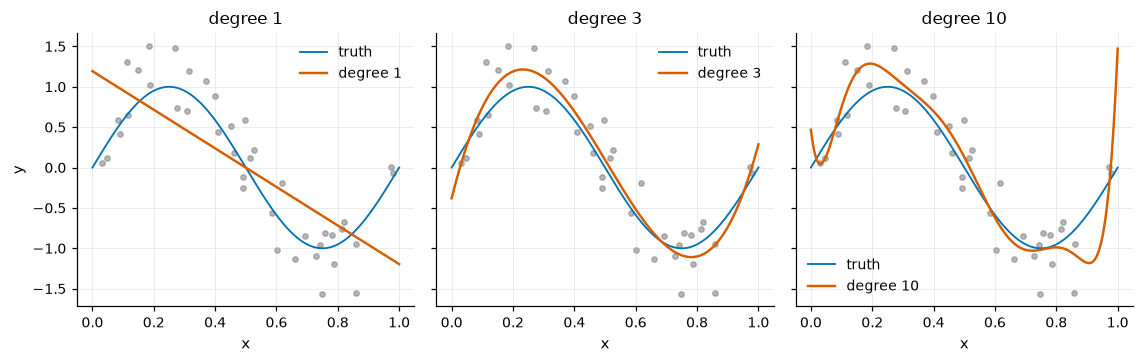

In [4]:
x_demo = rng.uniform(0.0, 1.0, size=N_TRAIN)
y_demo = true_f(x_demo) + rng.normal(0.0, SIGMA, size=N_TRAIN)
grid = np.linspace(0.0, 1.0, 201)

fig, axes = plt.subplots(1, 3, figsize=(10.5, 3.4), sharey=True)
for ax, deg in zip(axes, [1, 3, 10]):
    ax.scatter(x_demo, y_demo, s=12, alpha=0.6, color="#888888")
    ax.plot(grid, true_f(grid), linewidth=1.2, label="truth")
    ax.plot(grid, fit_predict(x_demo, y_demo, grid, deg), linewidth=1.6,
            label=f"degree {deg}")
    ax.set_xlabel("x")
    ax.set_title(f"degree {deg}")
    ax.legend()
axes[0].set_ylabel("y")
plt.show()

*Figure 6.1 — one training sample of $n=40$ (grey), the true regression function, and polynomial fits of degree 1 (too rigid: bias), 3 (about right), and 10 (bending to the noise: variance).*

### 6.1 The decomposition, empirically

Redraw the training set $R = 400$ times, refit every degree each time, and evaluate all fits on a fixed grid. Pointwise across replications, the mean fit gives the bias and the spread gives the variance; independently, scoring each fit against *fresh noisy responses* gives a Monte Carlo estimate of the prediction error that never touches the decomposition — the two sides of (3.1) are computed by different routes and then compared.

In [5]:
R = 400
f_grid = true_f(grid)
preds = np.empty((len(DEGREES), R, len(grid)))

for r in range(R):
    x_tr = rng.uniform(0.0, 1.0, size=N_TRAIN)
    y_tr = true_f(x_tr) + rng.normal(0.0, SIGMA, size=N_TRAIN)
    for d in DEGREES:
        preds[d, r] = fit_predict(x_tr, y_tr, grid, d)

bias2 = ((preds.mean(axis=1) - f_grid) ** 2).mean(axis=1)          # avg over grid
variance = preds.var(axis=1).mean(axis=1)
decomposition = bias2 + variance + SIGMA**2

fresh_noise = rng.normal(0.0, SIGMA, size=(R, len(grid)))
mc_risk = ((f_grid + fresh_noise - preds) ** 2).mean(axis=(1, 2))

summary = pd.DataFrame(
    {"bias²": bias2, "variance": variance, "bias²+var+σ²": decomposition,
     "MC risk": mc_risk},
    index=pd.Index(DEGREES, name="degree"),
)
summary.round(4)

,bias²,variance,bias²+var+σ²,MC risk
degree,,,,
0,0.4976,0.0133,0.6009,0.6003
1,0.1997,0.0176,0.3073,0.3070
2,0.2002,0.0335,0.3237,0.3232
3,0.0047,0.0115,0.1062,0.1063
4,0.0051,0.0208,0.1159,0.1161
5,0.0001,0.0237,0.1138,0.1138
6,0.0001,0.0307,0.1207,0.1203
7,0.0005,0.2590,0.3495,0.3491
8,0.0083,1.4497,1.5480,1.5498


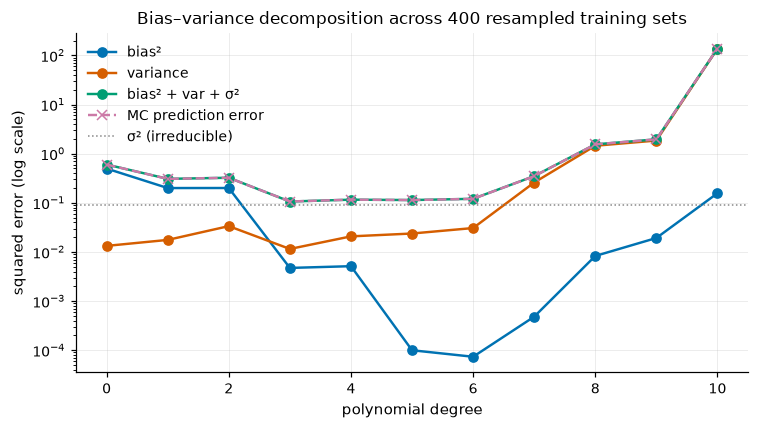

In [6]:
fig, ax = plt.subplots()
ax.plot(DEGREES, bias2, marker="o", label="bias²")
ax.plot(DEGREES, variance, marker="o", label="variance")
ax.plot(DEGREES, decomposition, marker="o", label="bias² + var + σ²")
ax.plot(DEGREES, mc_risk, marker="x", linestyle="--", label="MC prediction error")
ax.axhline(SIGMA**2, color="#888888", linewidth=1.0, linestyle=":",
           label="σ² (irreducible)")
ax.set_yscale("log")
ax.set_xlabel("polynomial degree")
ax.set_ylabel("squared error (log scale)")
ax.set_title("Bias–variance decomposition across 400 resampled training sets")
ax.legend()
plt.show()

*Figure 6.2 — squared bias collapses once the family can represent one full oscillation (degree ≈ 3–5), variance climbs with degree — explosively so beyond degree 7, where random designs leave high-order fits unconstrained near the interval edges — and their sum plus $\sigma^2$ tracks the independently computed Monte Carlo prediction error across the whole range (note the log scale); the optimum sits where the two reducible terms cross.*

### 6.2 Optimism against the $2\sigma^2\,\mathrm{df}/n$ line

For claim (ii), hold the design fixed (an evenly spaced grid of $n = 40$ inputs), so that $\mathbf{H}$ is a fixed matrix per degree and (5.2) applies literally. For each degree: build $\mathbf{H}$, check $\operatorname{tr}(\mathbf{H}) = \text{degree} + 1$, then Monte Carlo the gap between in-sample test error and training error over 20 000 noise draws.

In [7]:
x_fixed = np.linspace(0.0, 1.0, N_TRAIN)
f_fixed = true_f(x_fixed)
M = 20_000

records = []
noise = rng.normal(0.0, SIGMA, size=(M, N_TRAIN))
noise_star = rng.normal(0.0, SIGMA, size=(M, N_TRAIN))
for d in DEGREES:
    Q, _ = np.linalg.qr(design(x_fixed, d))
    H = Q @ Q.T
    y_hat = (f_fixed + noise) @ H.T
    train_err = ((f_fixed + noise - y_hat) ** 2).mean(axis=1)
    test_err = ((f_fixed + noise_star - y_hat) ** 2).mean(axis=1)
    records.append({"degree": d, "df": np.trace(H),
                    "empirical optimism": (test_err - train_err).mean(),
                    "theoretical 2σ²df/n": 2 * SIGMA**2 * np.trace(H) / N_TRAIN})

optimism = pd.DataFrame(records).set_index("degree")
optimism.round(4)

,df,empirical optimism,theoretical 2σ²df/n
degree,,,
0,1.0,0.0055,0.0045
1,2.0,0.0096,0.0090
2,3.0,0.0143,0.0135
3,4.0,0.0183,0.0180
4,5.0,0.0228,0.0225
5,6.0,0.0272,0.0270
6,7.0,0.0317,0.0315
7,8.0,0.0362,0.0360
8,9.0,0.0407,0.0405


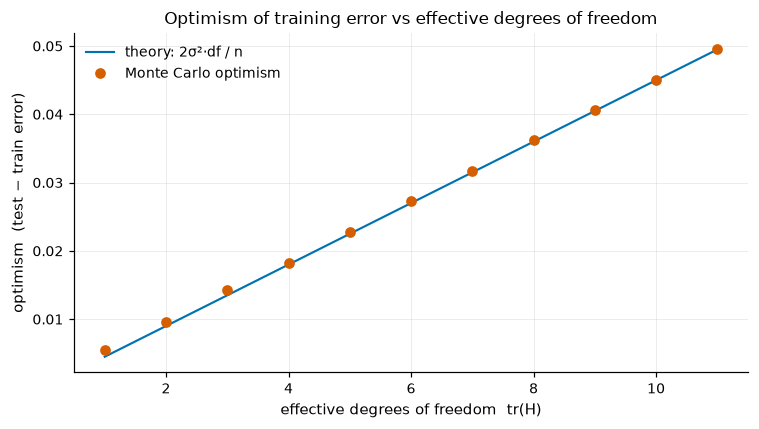

In [8]:
fig, ax = plt.subplots()
ax.plot(optimism["df"], optimism["theoretical 2σ²df/n"], linewidth=1.4,
        label="theory: 2σ²·df / n")
ax.plot(optimism["df"], optimism["empirical optimism"], marker="o", linestyle="",
        label="Monte Carlo optimism")
ax.set_xlabel("effective degrees of freedom  tr(H)")
ax.set_ylabel("optimism  (test − train error)")
ax.set_title("Optimism of training error vs effective degrees of freedom")
ax.legend()
plt.show()

*Figure 6.3 — the Monte Carlo optimism (points) lies on the theoretical line $2\sigma^2\,\mathrm{df}/n$ at every degree, including low degrees where the model is severely biased.*

**Verdict.** Both claims held. The decomposition columns of the §6.1 table agree with the independently simulated Monte Carlo risk to within Monte Carlo error at every degree, with the classic pattern — bias² dominating the rigid fits, variance the flexible ones, and the total minimised at moderate degree. The optimism results confirm (5.2) exactly: even at degree 0 or 1, where squared bias is an order of magnitude larger than $\sigma^2$, the *gap* between training and in-sample test error is still $2\sigma^2\,\mathrm{df}/n$ — misspecification bias cancels from the optimism, as the derivation promised.

### Exercises — §6

**6.1 (C.)** The derivation of (5.1) assumed homoscedastic noise only at the final step. Show that with heteroscedastic noise, $\operatorname{Var}(\varepsilon_i) = \sigma_i^2$, the linear-smoother optimism becomes $\omega = \frac{2}{n}\sum_i \sigma_i^2 h_{ii}$, where $h_{ii}$ are the diagonal entries (leverages) of $\mathbf{H}$. Then design a simulation with $\sigma_i$ increasing in $x_i$ that measures the empirical optimism, and compare it against both the correct formula and the homoscedastic formula using the average noise variance. Under what leverage pattern do the two formulas diverge most, and what does this imply about trusting $C_p$-style corrections under heteroscedasticity?

## 7 · Applied: a first default model on Lending Club

The remainder of the course's Block A–C applied work runs on the Lending Club accepted-loans book (2007–2018Q4, ~2.26M loans; downloaded and cached on first call — see `data/get_data.py`). Here we take the smallest honest step: fit default-prediction models of increasing flexibility and quantify the gap between naive in-sample performance and performance on held-out loans. The features are borrower and loan characteristics knowable at origination; we deliberately *exclude* `grade`, `sub_grade` and `int_rate`, which encode Lending Club's own credit model — predicting default from the lender's risk grade would be recycling someone else's model output and telling ourselves it is ours, a provenance discipline that returns as a theme in modules 07 and 09.

In [9]:
from src.data import load_lending_club

loans = load_lending_club(n_rows=400_000, seed=MODULE_SEED)
completed = loans[loans["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()
completed["default"] = (completed["loan_status"] == "Charged Off").astype(int)
completed["fico"] = (completed["fico_range_low"] + completed["fico_range_high"]) / 2
completed["log_income"] = np.log1p(completed["annual_inc"])

NUMERIC = ["loan_amnt", "log_income", "dti", "fico", "revol_util", "term_months"]
CATEGORICAL = ["purpose", "home_ownership"]
completed = completed.dropna(subset=NUMERIC).reset_index(drop=True)

print(f"completed loans: {len(completed):,}   default rate: {completed['default'].mean():.1%}")

completed loans: 237,849   default rate: 20.0%


A deliberately small training set of 2 000 loans — small enough that estimator variance is visible — and a large disjoint holdout of 60 000 for stable out-of-sample estimates. Categorical enumeration (`get_dummies`) runs on the pooled table so the two pieces share columns; every *statistic* used in preprocessing (the standardisation means and scales) comes from the training rows alone, a discipline module 04 elevates into a rule.

In [10]:
dummies = pd.get_dummies(completed[CATEGORICAL], drop_first=True, dtype=float)
perm = rng.permutation(len(completed))
train_idx, hold_idx = perm[:2_000], perm[2_000:62_000]

X_num = completed[NUMERIC].to_numpy(dtype=float)
mu, sd = X_num[train_idx].mean(axis=0), X_num[train_idx].std(axis=0)
Z = (X_num - mu) / sd                      # standardised with training statistics
D = dummies.to_numpy()
y_all = completed["default"].to_numpy()

y_train, y_hold = y_all[train_idx], y_all[hold_idx]

The model ladder keeps one estimator (logistic regression, familiar GLM territory) and varies only the feature space: intercept alone; the six numerics; plus categoricals; then full polynomial expansions of the numerics to degrees 2 and 3. Interest lies not in which rung "wins" but in how the in-sample/held-out gap grows with flexibility. A whisper of ridge penalty ($C = 10^4$) is retained purely for numerical stability and behaves as unpenalised fitting at these scales.

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss
from sklearn.preprocessing import PolynomialFeatures


def features(degree, with_dummies):
    if degree == 0:
        return np.ones((len(Z), 1))
    blocks = [PolynomialFeatures(degree, include_bias=False).fit_transform(Z)]
    if with_dummies:
        blocks.append(D)
    return np.hstack(blocks)


ladder = {
    "intercept only": (0, False),
    "6 numerics": (1, False),
    "numerics + categoricals": (1, True),
    "degree-2 expansion + cat.": (2, True),
    "degree-3 expansion + cat.": (3, True),
}

rows = []
for name, (deg, cats) in ladder.items():
    X = features(deg, cats)
    if deg == 0:
        p_train = np.full(len(train_idx), y_train.mean())
        p_hold = np.full(len(hold_idx), y_train.mean())
        n_par = 1
    else:
        model = LogisticRegression(C=1e4, max_iter=5_000)
        model.fit(X[train_idx], y_train)
        p_train = model.predict_proba(X[train_idx])[:, 1]
        p_hold = model.predict_proba(X[hold_idx])[:, 1]
        n_par = X.shape[1] + 1
    rows.append({"model": name, "parameters": n_par,
                 "in-sample log-loss": log_loss(y_train, p_train),
                 "held-out log-loss": log_loss(y_hold, p_hold)})

results = pd.DataFrame(rows).set_index("model")
results["optimism gap"] = results["held-out log-loss"] - results["in-sample log-loss"]
results.round(4)

,parameters,in-sample log-loss,held-out log-loss,optimism gap
model,,,,
intercept only,1,0.4997,0.5001,0.0004
6 numerics,7,0.4754,0.4703,-0.0051
numerics + categoricals,25,0.4693,0.4736,0.0043
degree-2 expansion + cat.,46,0.4602,0.4777,0.0176
degree-3 expansion + cat.,102,0.4478,0.4954,0.0477


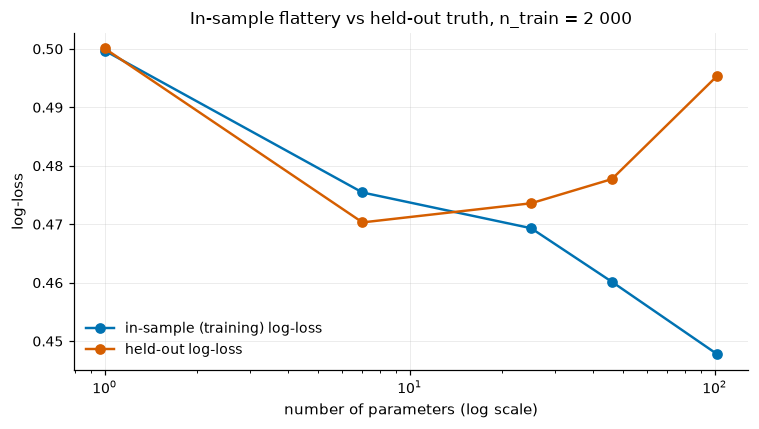

In [12]:
fig, ax = plt.subplots()
ax.plot(results["parameters"], results["in-sample log-loss"], marker="o",
        label="in-sample (training) log-loss")
ax.plot(results["parameters"], results["held-out log-loss"], marker="o",
        label="held-out log-loss")
ax.set_xscale("log")
ax.set_xlabel("number of parameters (log scale)")
ax.set_ylabel("log-loss")
ax.set_title("In-sample flattery vs held-out truth, n_train = 2 000")
ax.legend()
plt.show()

*Figure 7.1 — in-sample log-loss improves monotonically with model flexibility, as it must; held-out log-loss improves only while added flexibility captures signal, then deteriorates as the model fits training noise, and the widening gap is the optimism of §5 measured on real data.*

The pattern is the simulation's Figure 6.2 wearing real clothes: training error falls with every added parameter — it is structurally incapable of doing otherwise — while held-out error gains from genuine signal (the step from intercept to numerics, where FICO, term and indebtedness carry real information about default) and then loses to estimator variance in the expansions. (The intercept-only row's small *negative* gap is base-rate sampling noise between the two subsets — with no fitting there is no optimism, only chance.) On a 2 000-loan sample, the degree-3 model's in-sample score would be the best number on the table and the worst model on the book.

Every honest caveat about this analysis is a forward reference. The split is random rather than temporal, and loans co-move with the credit cycle — the 2007–2018 window contains a financial crisis — so even the held-out estimate answers a softer question than "how will this model do next year" (module 04 introduces temporal validation; module 10 makes it the whole subject). Log-loss is the right family of score but calibration deserves first-class treatment (module 03). And the feature set was assembled by eyeballing column names, with no leakage audit — module 04 builds the taxonomy that makes such an audit systematic.

### Exercises — §7

**7.1 (A.)** List three specific respects in which this section's protocol falls short of an estimate you would sign your name to, and for each, name the module of this course that supplies the repair. (At least one should concern the *data*, not the model.)

## 8 · Further reading

- Hastie, Tibshirani & Friedman, *The Elements of Statistical Learning*, 2nd ed. — ch. 2 (the frame), ch. 7 §§7.1–7.7 (optimism, df, $C_p$/AIC).
- Efron & Hastie, *Computer Age Statistical Inference* — ch. 12 (cross-validation and $C_p$, in the inferential register this course prefers).
- Breiman, L. (2001). "Statistical modeling: the two cultures." *Statistical Science* 16(3), with discussion.
- Bates, S., Hastie, T. & Tibshirani, R. (2023). "Cross-validation: what does it estimate and how well does it do it?" *JASA* 119(546).
- Belkin, M., Hsu, D., Ma, S. & Mandal, S. (2019). "Reconciling modern machine-learning practice and the classical bias–variance trade-off." *PNAS* 116(32). — the double-descent flag of §5.
- Curth, A., Jeffares, A. & van der Schaar, M. (2023). "A U-turn on double descent." *NeurIPS 2023*. — the reconciliation argument cited alongside it.